--- Initializing Calculus Knowledge Base ---
⚠️ Warning: File not found at Calculus_Textbook.pdf
⚠️ No valid PDFs found. Using sample Calculus text for demo.
Created 4 document chunks.
Documents added to vector store.
--- System Ready ---


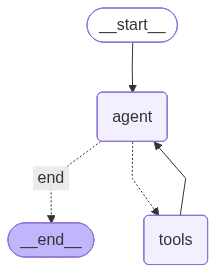


==================== Processing Query ====================
👤 User: State the Fundamental Theorem of Calculus Part 1.
🔍 Agent Decision: RETRIEVE (1 calls)
   -> Tool: retrieve_calculus_concepts | Query: {'query': 'Fundamental Theorem of Calculus Part 1'}
🤖 AI Answer: According to "Calculus_Textbook_Ch5," the Fundamental Theorem of Calculus Part 1 states that if \( f \) is continuous on \([a, b]\), then the function \( g \) defined by

\[ g(x) = \int_{a}^{x} f(t) \, dt \]

is continuous on \([a, b]\) and differentiable on \((a, b)\), and

\[ g'(x) = f(x). \]


==================== Processing Query ====================
👤 User: How does Green's Theorem relate to Stokes' Theorem?
🔍 Agent Decision: RETRIEVE (1 calls)
   -> Tool: retrieve_calculus_concepts | Query: {'query': 'Fundamental Theorem of Calculus Part 1'}
🔍 Agent Decision: RETRIEVE (1 calls)
   -> Tool: retrieve_calculus_concepts | Query: {'query': "Green's Theorem and Stokes' Theorem relationship"}
🤖 AI Answer: According to the "

In [1]:
import os
import requests
from dotenv import load_dotenv
from IPython.display import display, Image
from typing import Literal

# LangChain / LangGraph Imports
from langgraph.graph import START, END, MessagesState, StateGraph
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.tools import tool
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma

import warnings
warnings.filterwarnings("ignore")

load_dotenv()

class CalculusRAGApplication:
    def __init__(self, pdf_paths: list[str]):
        """
        Initialize the Calculus RAG Application.
        
        Args:
            pdf_paths: List of file paths to PDF documents for the knowledge base.
        """
        # 1. Initialize API Keys and Models
        self.api_key = os.getenv("OPENAI_API_KEY") 
        if not self.api_key:
            raise ValueError("OPENAI_API_KEY not found in environment variables.")

        self.llm = ChatOpenAI(model="gpt-4o", api_key=self.api_key, temperature=0)
        self.embeddings = OpenAIEmbeddings(model="text-embedding-3-small", api_key=self.api_key)
        
        # 2. Setup Vector Store (The "R" in RAG)
        print("--- Initializing Calculus Knowledge Base ---")
        self.vectorstore = self._setup_vectorstore(pdf_paths)
        
        # 3. Setup Tools
        self.tools = self.create_tools()
        self.llm_with_tools = self.llm.bind_tools(self.tools)
        
        # 4. Setup Graph Memory
        self.memory = MemorySaver()
        
        # 5. Build the Agent Graph
        self.graph = self.build_graph()
        print("--- System Ready ---")

    def _setup_vectorstore(self, pdf_paths):
        """
        Internal method to load PDFs, chunk them, and create a Chroma vector store.
        """
        docs = []
        # Attempt to load provided PDFs
        for path in pdf_paths:
            if os.path.exists(path):
                print(f"Loading: {path}")
                loader = PyPDFLoader(path)
                docs.extend(loader.load())
            else:
                print(f"⚠️ Warning: File not found at {path}")
        
        # Fallback dummy data if no PDFs are provided (Specific to Advanced Calculus)
        if not docs:
            print("⚠️ No valid PDFs found. Using sample Calculus text for demo.")
            from langchain_core.documents import Document
            docs = [
                Document(
                    page_content="The Fundamental Theorem of Calculus links the concept of differentiating a function with the concept of integrating a function. Part 1 states that if f is continuous on [a, b], then the function g defined by g(x) = integral from a to x of f(t) dt is continuous on [a, b] and differentiable on (a, b), and g'(x) = f(x).", 
                    metadata={"source": "Calculus_Textbook_Ch5", "page": 120}
                ),
                Document(
                    page_content="Green's Theorem gives the relationship between a line integral around a simple closed curve C and a double integral over the plane region D bounded by C. It is a special case of Stokes' Theorem.", 
                    metadata={"source": "Vector_Calculus_Notes", "page": 45}
                ),
                Document(
                    page_content="A Taylor Series is a representation of a function as an infinite sum of terms that are calculated from the values of the function's derivatives at a single point. The concept was introduced by Brook Taylor in 1715.", 
                    metadata={"source": "Approximation_Theory", "page": 12}
                ),
                Document(
                    page_content="L'Hôpital's rule provides a technique to evaluate limits of indeterminate forms (0/0 or infinity/infinity). It states that the limit of the quotient of functions is equal to the limit of the quotient of their derivatives.", 
                    metadata={"source": "Limits_and_Continuity", "page": 88}
                )
            ]

        # Splitting
        text_splitter = RecursiveCharacterTextSplitter(
            chunk_size=1000,
            chunk_overlap=200 
        )
        splits = text_splitter.split_documents(docs)
        print(f"Created {len(splits)} document chunks.")

        # Storage
        persist_dir = "./chroma_db_calculus"
        vectorstore = Chroma(
            collection_name="calculus_docs",
            embedding_function=self.embeddings,
            persist_directory=persist_dir
        )
        
        # Only add documents if the collection is empty
        if vectorstore._collection.count() == 0:
            vectorstore.add_documents(documents=splits)
            print("Documents added to vector store.")
        else:
            print("Using existing vector store.")
            
        return vectorstore

    def create_tools(self):
        """
        Define the tools available to the agent.
        """
        
        @tool
        def retrieve_calculus_concepts(query: str) -> str:
            """
            Search the internal knowledge base for formal definitions, theorems, proofs, and detailed explanations of advanced calculus concepts.
            
            Use this tool ONLY when the user asks for specific theorems (e.g., Green's Theorem), formal definitions, historical context of concepts, or details likely found in a textbook.
            Do NOT use for simple calculations (e.g., "derivative of x^2") or general questions unrelated to the provided documents.
            
            Args:
                query: The search query string.
            """
            # Using MMR for diverse results
            retriever = self.vectorstore.as_retriever(
                search_type="mmr",
                search_kwargs={"k": 5, "fetch_k": 10}
            )
            results = retriever.invoke(query)
            
            if not results:
                return "No relevant documents found in the knowledge base."
            
            formatted_results = "\n\n".join(
                f"--- Source: {doc.metadata.get('source', 'Unknown')} (Page {doc.metadata.get('page', 'N/A')}) ---\n{doc.page_content}"
                for doc in results
            )
            return formatted_results

        return [retrieve_calculus_concepts]
    
    def build_graph(self):
        """
        Constructs the LangGraph state machine.
        """

        # 1. Define the System Prompt
        system_message = """You are a specialized Advanced Calculus Tutor. 
        You have access to a library of textbooks and notes regarding calculus theorems and definitions.
        
        DECISION RULES:
        1. If the user asks for a specific Theorem, Definition, or Proof (e.g., "State Green's Theorem", "Define Taylor Series") -> USE the 'retrieve_calculus_concepts' tool.
        2. If the user asks for a simple calculation or standard fact (e.g., "What is the derivative of sin(x)?", "Who invented calculus?") -> Answer DIRECTLY from your own knowledge.
        3. If the user asks to summarize the available documents -> USE the tool.
        
        When using the tool, explicitly cite the source (e.g., "According to Calculus_Textbook_Ch5...") in your answer.
        """

        # 2. Define Nodes
        def access_model(state: MessagesState) -> MessagesState:
            messages = [SystemMessage(content=system_message)] + state["messages"]
            response = self.llm_with_tools.invoke(messages)
            return {"messages": [response]}

        # 3. Define Conditional Logic
        def should_continue(state: MessagesState) -> Literal["tools", "end"]:
            last_message = state["messages"][-1]
            if last_message.tool_calls:
                return "tools"
            return "end"

        # 4. Build Graph Structure
        graph_builder = StateGraph(MessagesState)
        
        graph_builder.add_node("agent", access_model)
        graph_builder.add_node("tools", ToolNode(self.tools))
        
        graph_builder.add_edge(START, "agent")
        
        graph_builder.add_conditional_edges(
            "agent",
            should_continue,
            {
                "tools": "tools",
                "end": END
            }
        )
        
        graph_builder.add_edge("tools", "agent")
        
        return graph_builder.compile(checkpointer=self.memory)
    
    def visualize_graph(self):
        try:
            display(Image(self.graph.get_graph().draw_mermaid_png()))
        except Exception as e:
            print(f"Could not visualize graph: {e}")
    
    def query_agent(self, query: str, thread_id: str = "default_student"):
        print(f"\n{'='*20} Processing Query {'='*20}")
        print(f"👤 User: {query}")
        
        config = {"configurable": {"thread_id": thread_id}}
        
        # Invoke the graph
        result = self.graph.invoke({"messages": [HumanMessage(content=query)]}, config=config)
        
        # Analyze what happened
        messages = result["messages"]
        tool_used = False
        final_answer = ""
        
        for msg in messages:
            if isinstance(msg, AIMessage):
                if msg.tool_calls:
                    tool_used = True
                    print(f"🔍 Agent Decision: RETRIEVE ({len(msg.tool_calls)} calls)")
                    for tc in msg.tool_calls:
                        print(f"   -> Tool: {tc['name']} | Query: {tc['args']}")
                elif msg.content:
                    final_answer = msg.content

        if not tool_used:
            print("🧠 Agent Decision: GENERAL KNOWLEDGE (No retrieval)")
            
        print(f"🤖 AI Answer: {final_answer}")
        print(f"{'='*58}\n")
        return final_answer

# --- Main Execution Block ---

# 1. Prepare PDF (Using dummy data fallback for this demo)
pdf_files = ["Calculus_Textbook.pdf"] 

# 2. Instantiate App
app = CalculusRAGApplication(pdf_paths=pdf_files)

# 3. Visualize
app.visualize_graph()

# 4. Test Queries (Mix of Retrieval vs General)
test_queries = [
    # 5 Retrieval Queries (Specific definitions/Theorems)
    "State the Fundamental Theorem of Calculus Part 1.",
    "How does Green's Theorem relate to Stokes' Theorem?",
    "Explain the concept of a Taylor Series.",
    "What technique is used for indeterminate forms like 0/0?",
    "Summarize the calculus concepts in your library.",

    # 5 General Knowledge Queries (Simple Math/Facts)
    "What is the derivative of x^2?",
    "Who are considered the fathers of calculus?",
    "Calculate the integral of 2x dx.",
    "What is the limit of 1/x as x approaches infinity?",
    "Is calculus used in physics?"
]

for q in test_queries:
    app.query_agent(q, thread_id="calc_test_session_1")